In [1]:
import pandas as pd

In [21]:
data = pd.read_csv("driver-data.csv", index_col="id")
data.head()


,mean_dist_day,mean_over_speed_perc
id,,
3423311935,71.24,28
3423313212,52.53,25
3423313724,64.54,27
3423311373,55.69,22
3423310999,54.58,25


In [3]:
from sklearn.cluster import KMeans

In [5]:
kmeans = KMeans(n_clusters=4)

In [6]:
kmeans.fit(data)

,n_clusters,4
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,None
,copy_x,True
,algorithm,'lloyd'


In [7]:
kmeans.cluster_centers_

array([[166.49554974,  10.42408377],
       [ 50.04763438,   8.82875   ],
       [176.63676768,  71.53535354],
       [197.25805643,  11.18495298]])

In [8]:
kmeans.labels_

array([1, 1, 1, ..., 0, 0, 0], shape=(4000,), dtype=int32)

In [9]:
import numpy as np

In [10]:
unique, counts = np.unique(kmeans.labels_, return_counts=True)

In [11]:
dict_data = dict(zip(unique, counts))
dict_data

{np.int32(0): np.int64(379),
 np.int32(1): np.int64(3200),
 np.int32(2): np.int64(99),
 np.int32(3): np.int64(322)}

In [12]:
import seaborn as sns

In [13]:
data["cluster"] = kmeans.labels_

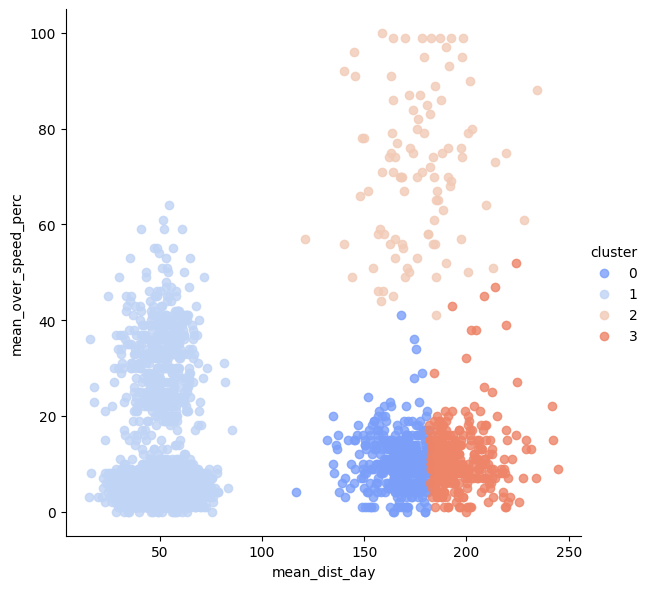

In [19]:
sns.lmplot(x='mean_dist_day', 
           y='mean_over_speed_perc', 
           data=data, 
           hue='cluster', 
           palette='coolwarm', 
           height=6, 
           aspect=1, 
           fit_reg=False)

In [22]:
# Inertia is the sum of squared error for each cluster. 
# Therefore the smaller the inertia the denser the cluster(closer together all the points are)

kmeans.inertia_

830189.2931569947

In [16]:
kmeans.score

<bound method _BaseKMeans.score of KMeans(n_clusters=4)>

In [17]:
data

,mean_dist_day,mean_over_speed_perc,cluster
id,,,
3423311935,71.24,28,1
3423313212,52.53,25,1
3423313724,64.54,27,1
3423311373,55.69,22,1
3423310999,54.58,25,1
...,...,...,...
3423310685,160.04,10,0
3423312600,176.17,5,0
3423312921,170.91,12,0
